# Where the Numbers Come From

*provenance, and the measurement error an audit cannot remove*

## The question

The credibility of a result is bounded by how well its inputs are understood, and inputs
rarely arrive as a tidy file. This notebook works the front of the chain: finding and reading
a live repository census spanning every format a project accumulates, then auditing what it contains — with
attention to the failures that produce a plausible wrong answer rather than an error, because
those are the ones that survive into a conclusion.

### Reading a repository

Every number in the earlier parts arrived from somewhere, and the credibility of a result is
bounded by how well that somewhere is understood. This notebook starts Part III at the
beginning of that chain: **provenance**.

A tidy exercise hands you a folder. Real work hands you a *repository* — and this one holds
hundreds of files and about 13 GB: tables, pickles, NumPy arrays, JSON, a large zip, and
32 near-identical replay CSVs buried in 8 nested run directories. A third of it is gitignored,
so what exists depends on the machine.

The work before any modelling is therefore: **find it, classify it, load it, and record what
you found.** Four steps, and the third is the easy one.

The recurring lesson is that metadata often lives in the *path* rather than the file. The
`.npy` arrays here have no date axis at all — the only thing that dates them is the
`windows/2025-08-13/` directory they sit in. Concatenate those files naively and you get a
frame with no way to tell the rows apart.

### Auditing a dataset

Every check in this notebook was chosen on one criterion: **when it fails, it produces a
plausible wrong answer rather than an error.**

A duplicated key silently double-weights an observation. A constant column costs a feature
slot and teaches nothing. A column that drifts between train and test makes a validated model
fail in production with no warning. A label that is missing for whole entities biases the
model toward whichever entities happened to survive. None of these raise. All of them change
your conclusions, and all of them are cheap to detect.

The last recipe is the one people skip: when two sources are supposed to describe the same
thing, **check whether they do**. This repository holds two independent measurements of the
same option smile, and they disagree — by a little, consistently, for a reason worth knowing.

In [1]:
try:
    import rvlab
except ModuleNotFoundError:
    import pathlib, sys
    _root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
                 if (p / "src" / "rvlab").is_dir())
    sys.path.insert(0, str(_root / "src"))
    import rvlab
rvlab.setup_notebook()

roughvol,/Users/xiaohao/rough_pricing_env/Rough-Pricing/src
research_shared,/Users/xiaohao/Effective_Engine/MVP/demo/python/research/shared
● smile_90d,"Multi-maturity: T in [0.019, 0.164]. The term-structure dataset."
● smile_127d,Near-tenor only: T ~ 0.02-0.03. The long-history forecasting dataset.
● smile_5d,Near-tenor only.
● chain_panel,"2025-08-07 to 2025-08-13, one expiry per bar."


## Parameters

In [2]:
MAX_LOADABLE_MB = 200      # catalogue larger files, but do not offer them to a loader
PROFILE_LIMIT   = 25       # how many files to open when capturing schemas
PROFILE_MAX_MB  = 20
CHUNK_ROWS      = 20_000   # rows per chunk in the streaming read
DATASET       = "smile_90d"
MIN_DTE, MAX_DTE = 7, 60
SPLIT_FRAC    = 0.7        # train/test boundary for the drift check
PSI_WARN      = 0.25       # >0.25 is a material distribution shift
RARE_LEVEL    = 0.01

## Where the data comes from

This notebook covers several sections, and each one loads what it needs at its own head — the cell below for the first section, and one like it under every heading after that. They are the only cells that read data: change them and the whole section re-aims at your own frames, with every recipe below unchanged.

In [3]:
from rvlab.config import REPO_ROOT
from rvlab.data import DataCatalog

ROOT = REPO_ROOT
catalog = DataCatalog.build(ROOT, max_mb=MAX_LOADABLE_MB)
df = catalog.files
print(catalog)
df.head(3)

DataCatalog(1,373 files, 13,036 MB, root=MVP)


,path,ext,size_mb,directory,name,loadable
0,.DS_Store,,0.010,.,.DS_Store,False
1,.gitignore,,0.002,.,.gitignore,False
2,CLAUDE.md,.md,0.015,.,CLAUDE.md,False


## Recipes in this notebook

**Reading a repository**

| Recipe | What it does |
|---|---|
| [R6.1](#r6-1) | Census the tree by file type |
| [R6.2](#r6-2) | Find where the data actually lives |
| [R6.3](#r6-3) | Load anything, dispatching on extension |
| [R6.4](#r6-4) | Read a CSV without letting pandas guess |
| [R6.5](#r6-5) | Stream a file too large to hold |
| [R6.6](#r6-6) | Load arrays, and find the metadata that is not in them |
| [R6.7](#r6-7) | Flatten nested JSON into a frame |
| [R6.8](#r6-8) | Read inside an archive without extracting it |
| [R6.9](#r6-9) | Concatenate a run tree, lifting metadata out of the paths |
| [R6.10](#r6-10) | Check whether all those files are actually different |
| [R6.11](#r6-11) | Build a catalogue and let it find the join keys |
| [R6.12](#r6-12) | Cache to parquet, not CSV |
| [R6.13](#r6-13) | When pandas is the bottleneck |

**Auditing a dataset**

| Recipe | What it does |
|---|---|
| [R6.14](#r6-14) | Run one audit that catches the common defects |
| [R6.15](#r6-15) | Check numeric ranges, zeros and infinities |
| [R6.16](#r6-16) | Count outliers three ways and read the disagreement |
| [R6.17](#r6-17) | Map the missing values before deciding what to do |
| [R6.18](#r6-18) | Audit the time axis |
| [R6.19](#r6-19) | Check categorical cardinality before encoding |
| [R6.20](#r6-20) | Detect drift between train and test |
| [R6.21](#r6-21) | Scan for leakage three ways |
| [R6.22](#r6-22) | Audit the label itself |
| [R6.23](#r6-23) | Reconcile two sources that should agree |
| [R6.24](#r6-24) | Turn the checks into a contract you can re-run |

Each recipe is self-contained: it uses only the names its section's data cell binds, plus the parameters cell and anything it declares under **Needs**. Copy any one of them straight into another project.

## Things to watch

The theme is that absence, duplication and disagreement are all information — and none of them raise an exception.

**Python and pandas**

* **`np.load(..., mmap_mode="r")` reads shape and dtype for free.** Inspect a directory of
  arrays without loading a byte of payload.
* **`pd.read_csv(chunksize=...)` returns an iterator, not a frame.** For the large file here
  that is the difference between a working notebook and a stalled one.
* **Unpickling executes code.** Never load a pickle you did not produce. It is a code path,
  not a data format.
* **`ZipFile.namelist()` reads the central directory only.** Listing 131 members of a 12.9 GB
  archive takes no measurable time; extracting is what costs.
* **Prefer `pathlib.Path.rglob` to hand-rolled recursion**, and sort the result — filesystem
  order is not stable across machines, and unsorted input makes a run unreproducible.

**Analysis**

* **Metadata often lives in the path, not the file.** The `.npy` arrays here have no date
  axis; only the enclosing directory dates them. Lift path fields into columns at load time
  or the concatenated frame cannot be interpreted.
* **Concatenating a tree is not the same as gaining data.** 88% of this run tree is
  byte-identical: 16 rows, 2 distinct observations. An effective sample size of 2 dressed as
  16 passes every downstream check.
* **Audit for failures that produce plausible answers, not errors.** Duplicated keys,
  constant columns, drifted distributions and entity-correlated missingness all change your
  conclusion and none of them raise.
* **Two extractions of the same quantity disagreeing is a measurement, not a bug.** That gap
  bounds how much of any model's error is even explainable.
* **Fix a drift threshold before you look at the drift.**


## Reading a repository

Finding, classifying and loading a changing repository census across every format a project accumulates — and recording what is present as carefully as what is loaded.

## R6.1 · Census the tree by file type
<a id="r6-1"></a>

**Topic** File discovery

**Use when** you open an unfamiliar repository. Counts and sizes by extension tell you what kind of project it is and where the bytes are, before you read anything.

**Inputs** `df`, the file catalogue.

**Needs** nothing beyond the setup and data cells

**Gotchas** the largest file and the most numerous file are rarely the same, and both matter — one sets your memory ceiling, the other sets your loop count.

**See also** [R6.2](#r6-2) (by directory) · [R5.3](the_cross_section.ipynb#r5-3) (auditing content)

In [4]:
catalog.census().head(10)

,ext,n_files,total_mb,largest_mb
0,.json,377,1.295,0.032
1,.pkl,250,95.963,57.024
2,.csv,180,6.582,1.696
3,.log,114,7.415,0.237
4,.py,99,1.174,0.121
5,.npy,79,36.164,13.652
6,.hpp,51,0.252,0.020
7,.md,43,0.307,0.073
8,.pt,41,1.677,0.041
9,.cpp,24,0.170,0.033


Two numbers to read off: total size tells you whether this fits in memory at all, and the largest single file tells you whether *any* of it needs streaming.

In [5]:
census = catalog.census()
print(f"{census['n_files'].sum():,} files, {census['total_mb'].sum():,.0f} MB total")
print(f"largest single file: {census['largest_mb'].max():,.0f} MB")

1,373 files, 13,036 MB total
largest single file: 12,873 MB


## R6.2 · Find where the data actually lives
<a id="r6-2"></a>

**Topic** File discovery

**Use when** the extension census says *what*; this says *where*. Directories holding many files of one type are usually generated output; a directory mixing types is usually curated input.

**Inputs** `df`.

**Needs** nothing beyond the setup and data cells

**Gotchas** a directory with hundreds of near-identical files is a run tree, and it needs [R6.9](#r6-9) rather than a loop over `read_csv`.

**See also** [R6.1](#r6-1) (by type) · [R6.9](#r6-9) (run trees)

In [6]:
catalog.directories(top=10)

,directory,n_files,total_mb,extensions
0,notebooks/_output/competition_workbench_25f0de...,21,0.090,".csv, .joblib, .json"
1,notebooks/_output/competition_workbench_89aa39...,21,0.090,".csv, .joblib, .json"
2,notebooks/_output/competition_workbench_95b0bb...,21,0.091,".csv, .joblib, .json"
3,notebooks/_output/competition_workbench_f137fe...,21,0.090,".csv, .joblib, .json"
4,demo/python/research/conditional_dynamics/output,21,2.634,".csv, .txt"
5,notebooks/_output/competition_workbench_5a4acf...,20,0.063,".csv, .joblib, .json"
6,notebooks/_output/competition_workbench_8051ea...,20,0.064,".csv, .joblib, .json"
7,lab/reports,18,0.264,".json, .md"
8,notes/TezaProposal,18,1.414,", .aux, .fdb_latexmk, .fls, .gz, .log, .out, ...."
9,src/rvlab/tests,17,0.156,.py


## R6.3 · Load anything, dispatching on extension
<a id="r6-3"></a>

**Topic** File I/O

**Use when** you have a mixed tree and do not want thirteen branches at every call site. One dispatcher with the right defaults per format.

**Inputs** a path.

**Needs** nothing beyond the setup and data cells

**Gotchas** the defaults are the value here: `.npy` is memory-mapped, nested JSON stays a dict for `json_normalize`, and pickle loading requires `allow_unsafe_pickle=True` because unpickling can execute code. An unknown extension **raises** rather than guessing — a silently wrong format read is worse than a stop.

**See also** [R6.4](#r6-4) (CSV specifics) · [R6.7](#r6-7) (nested JSON)

In [7]:
from rvlab.data import load_any

for rel in ["data/spot_AAPL.csv", "lab/registry/datasets.json"]:
    obj = load_any(ROOT / rel)
    print(f"  {rel:34s} -> {type(obj).__name__}")

  data/spot_AAPL.csv                 -> DataFrame
  lab/registry/datasets.json         -> dict


Same call, four different formats, four appropriate return types.

In [8]:
pkl = catalog.find("gate0_days5_farF.pkl")
npy = catalog.find("training_tau_grid.npy")
if len(pkl):
    trusted = load_any(ROOT / pkl.iloc[0]['path'], allow_unsafe_pickle=True)
    print(f"  trusted pickle -> {type(trusted).__name__}")
if len(npy):
    arr = load_any(ROOT / npy.iloc[0]["path"])
    print(f"  npy    -> {type(arr).__name__}, shape {arr.shape}, memory-mapped")

  trusted pickle -> DataFrame
  npy    -> memmap, shape (51,), memory-mapped


## R6.4 · Read a CSV without letting pandas guess
<a id="r6-4"></a>

**Topic** File I/O

**Use when** every delimited file. Left alone, pandas infers dtypes from the first rows, reads dates as strings, and promotes an integer column to float the moment one value is missing.

**Inputs** a CSV path.

**Needs** nothing beyond the setup and data cells

**Gotchas** `usecols` is the cheapest speed-up available on a wide file — you cannot beat not reading a column. And `parse_dates` alone does not set a timezone: a naive timestamp compared against a UTC one either raises or, worse, misaligns by hours.

**See also** [R6.5](#r6-5) (large files) · [R1.8](the_volatility_surface.ipynb#r1-8) (the same idea)

In [9]:
import pandas as pd

panel_path = ROOT / "demo/data/spy_chain_panel.csv"
if panel_path.exists():
    cols = ["timestamp_utc", "underlying_price", "atm_iv", "rr25_iv", "bf25_iv"]
    tight = pd.read_csv(panel_path, usecols=cols,
                        dtype={"underlying_price": "float32", "atm_iv": "float32"},
                        parse_dates=["timestamp_utc"])
    print(f"{len(tight):,} rows x {tight.shape[1]} of 26 columns")
    display(tight.dtypes.to_frame("dtype"))
else:
    print("demo/data is gitignored — see R6.11 for how the catalogue reports that")

2,029 rows x 5 of 26 columns


,dtype
timestamp_utc,"datetime64[ns, UTC]"
underlying_price,float32
atm_iv,float32
rr25_iv,float64
bf25_iv,float64


> ⚠️ **Timezones:** `parse_dates` produces a tz-aware column only when the file carries an offset. This one does (`+00:00`); many do not. Convert explicitly at the boundary rather than discovering it during a join.

In [10]:
if panel_path.exists():
    ts = pd.to_datetime(tight["timestamp_utc"], utc=True)
    print(f"tz after explicit conversion: {ts.dt.tz}")
    print(f"span: {ts.min()} -> {ts.max()}")

tz after explicit conversion: UTC
span: 2025-08-07 13:31:00+00:00 -> 2025-08-13 20:16:00+00:00


## R6.5 · Stream a file too large to hold
<a id="r6-5"></a>

**Topic** Large files

**Use when** the file does not fit, or you only need an aggregate. `chunksize` turns `read_csv` into an iterator of frames, so memory stays flat regardless of file size.

**Inputs** a large CSV path.

**Needs** nothing beyond the setup and data cells

**Gotchas** accumulate *aggregates*, never the chunks themselves — appending every chunk to a list and concatenating at the end uses more memory than reading it whole. If you genuinely need all the rows, convert once to parquet ([R6.12](#r6-12)) and read that instead.

**See also** [R6.4](#r6-4) (declaring dtypes) · [R6.12](#r6-12) (parquet)

In [11]:
from rvlab import compat
from pathlib import Path

big = None
if compat.ensure_roughvol():
    candidate = Path(compat.paths()["roughvol"]).parent / \
        "output/interview/hedge_rebalance_records_default_cost.csv"
    if candidate.exists():
        big = candidate
if big is None:
    big = max((ROOT / p for p in catalog.files.query("ext == '.csv'")["path"]),
              key=lambda p: p.stat().st_size)
print(f"streaming {big.name} ({big.stat().st_size / 1e6:.1f} MB)")

streaming hedge_rebalance_records_default_cost.csv (55.4 MB)


One pass, constant memory, accumulating only what the answer needs.

In [12]:
import pandas as pd

n_rows, total, groups = 0, 0.0, {}
for chunk in pd.read_csv(big, chunksize=CHUNK_ROWS):
    n_rows += len(chunk)
    numeric = chunk.select_dtypes("number")
    if len(numeric.columns):
        total += float(numeric.iloc[:, 0].sum())
    key = next((c for c in ("policy", "dgp", "date") if c in chunk.columns), None)
    if key:
        for k, v in chunk[key].value_counts().items():
            groups[k] = groups.get(k, 0) + v

print(f"{n_rows:,} rows in {n_rows // CHUNK_ROWS + 1} chunks, peak memory ~1 chunk")
print(dict(list(groups.items())[:4]) if groups else "")

142,848 rows in 8 chunks, peak memory ~1 chunk
{'Frozen-IV BS': 47616, 'Causal rolling-RV BS': 47616, 'Latent-state diagnostic': 47616}


## R6.6 · Load arrays, and find the metadata that is not in them
<a id="r6-6"></a>

**Topic** Arrays

**Use when** the tree contains `.npy` tensors. Memory-map them to inspect shape and dtype for free, then go looking for what dates them — because it will not be in the array.

**Inputs** an `.npy` path.

**Needs** nothing beyond the setup and data cells

**Gotchas** `mmap_mode="r"` reads only the header, so cataloguing a directory of 100 MB arrays is instant. The real trap is the second half: these arrays have **no date axis**. Their only temporal identity is the enclosing directory name and a sibling JSON.

**See also** [R6.9](#r6-9) (path metadata at scale) · [R6.7](#r6-7) (the sibling JSON)

In [13]:
import json
from rvlab.data import load_any

arrays = catalog.find("artifacts_is").query("ext == '.npy'")
rows = [{"file": p.split("/")[-1], "shape": str(load_any(ROOT / p).shape),
         "dtype": str(load_any(ROOT / p).dtype)} for p in arrays["path"].head(5)]
import pandas as pd
pd.DataFrame(rows)

,file,shape,dtype
0,real_is_dW1.npy,"(60, 50)",float32
1,real_is_payoff.npy,"(60,)",float32
2,real_is_states_raw.npy,"(60, 51, 7)",float32
3,real_is_tau_grid.npy,"(51,)",float32
4,training_dW1.npy,"(9560, 50)",float32


Nothing above says *when*. The sibling metadata file is the only thing that does — and if it were missing, these tensors would be unusable for anything time-aware.

In [14]:
meta = catalog.find("real_is_meta.json")
if len(meta):
    print(json.dumps(load_any(ROOT / meta.iloc[0]["path"]), indent=2)[:340])
else:
    print("no metadata sidecar found — the arrays would be undateable")

{
  "n_paths": 60,
  "n_steps": 50,
  "state_dim": 7,
  "is_v0_mean": 0.016743959859013557,
  "split_date": "2026-01-01",
  "date_range": [
    "2025-08-07",
    "2025-12-31"
  ],
  "payoff_mean": 2.3395090103149414,
  "payoff_std": 2.9468162059783936
}


## R6.7 · Flatten nested JSON into a frame
<a id="r6-7"></a>

**Topic** File I/O

**Use when** configuration, registries and API dumps arrive as nested JSON. `json_normalize` turns a list of nested records into a flat table in one call.

**Inputs** a JSON file with a list of records under some key.

**Needs** nothing beyond the setup and data cells

**Gotchas** `record_path` selects the list to explode; `meta` carries down fields from the parent that would otherwise be lost. Getting `meta` wrong is how you end up with 8 identical rows and no idea which is which.

**See also** [R6.3](#r6-3) (dispatch) · [R6.11](#r6-11) (the registry as a catalogue)

In [15]:
import pandas as pd
from rvlab.data import load_any

registry = load_any(ROOT / "lab/registry/research_gates.json")
gates = pd.json_normalize(registry["research_gates"])
print(f"{len(gates)} research gates, {gates.shape[1]} fields")
gates[["gate_id", "family", "status"]]

8 research gates, 10 fields


,gate_id,family,status
0,gate1_skew_structure,smile-geometry,weak
1,gate2_temporal_forecast,temporal-forecast,rejected
2,gate3_regime_dynamics,regime-dynamics,narrow-support
3,gate4_incremental_edge_over_carry,temporal-forecast,pass
4,gate5_edge_concentration,regime-dynamics,weak
5,candidate_calendar_term_structure,candidate,candidate
6,candidate_vol_of_vol_regime,candidate,candidate
7,candidate_event_risk_filter,candidate,candidate


The list-valued columns need exploding to become joinable. `latest_outputs` points at the sweep CSVs elsewhere in the tree — this registry is the link between a claim and the artefact backing it.

In [16]:
links = (gates[["gate_id", "latest_outputs"]].explode("latest_outputs").dropna())
links["file"] = links["latest_outputs"].str.split("/").str[-1]
print(f"{len(links)} claim -> artefact links")
links[["gate_id", "file"]].head(4)

10 claim -> artefact links


,gate_id,file
0,gate1_skew_structure,gate0a_sweep_20260409_201238.csv
0,gate1_skew_structure,skew_scaling_20260409_111639.txt
1,gate2_temporal_forecast,gate0_sweep_20260409_174933.csv
1,gate2_temporal_forecast,gate0_sweep_20260409_174933.txt


## R6.8 · Read inside an archive without extracting it
<a id="r6-8"></a>

**Topic** Archives

**Use when** the data is zipped and the archive is large. `ZipFile` streams one member at a time, and listing the contents reads only the central directory.

**Inputs** a zip path.

**Needs** nothing beyond the setup and data cells

**Gotchas** this repository's OPRA archive is **12.9 GB holding 131 members**. Extracting it to read one day is not an option; listing it takes a few milliseconds because the directory lives at the end of the file and is seeked to directly.

**See also** [R6.5](#r6-5) (streaming) · [R6.1](#r6-1) (finding it)

In [17]:
from rvlab.data import read_zip_member

zips = catalog.files.query("ext == '.zip'")
if len(zips):
    archive = ROOT / zips.iloc[0]["path"]
    members = read_zip_member(archive)
    print(f"{archive.name}: {archive.stat().st_size / 1e9:.1f} GB, {len(members)} members")
    display(members.head(4))
else:
    print("no archive present in this tree")

OPRA-20260208-3T68RYYKF9.zip: 12.9 GB, 131 members


,member,size_mb,compressed_mb
2,symbology.json,178.92,178.92
129,opra-pillar-20260206.cbbo-1m.dbn.zst,124.91,124.91
123,opra-pillar-20260129.cbbo-1m.dbn.zst,121.53,121.53
128,opra-pillar-20260205.cbbo-1m.dbn.zst,120.78,120.78


Now read one small member out of it — the whole point of not extracting.

In [18]:
if len(zips):
    small = members[members["member"].str.endswith(".json")].sort_values("size_mb")
    if len(small):
        payload = read_zip_member(archive, small.iloc[0]["member"])
        print(f"read {small.iloc[0]['member']} "
              f"({small.iloc[0]['size_mb']:.2f} MB) -> {type(payload).__name__}")
        print(str(payload)[:200])

read metadata.json (0.00 MB) -> dict
{'version': 1, 'job_id': 'OPRA-20260208-3T68RYYKF9', 'query': {'dataset': 'OPRA.PILLAR', 'schema': 'cbbo-1m', 'symbols': ['SPY.OPT'], 'stype_in': 'parent', 'stype_out': 'instrument_id', 'start': 17545


## R6.9 · Concatenate a run tree, lifting metadata out of the paths
<a id="r6-9"></a>

**Topic** Many small files

**Use when** an experiment directory: many small files whose identity is encoded in their location. `runs/<run_id>/windows/<date>/replay/bs_daily.csv` — the file itself knows none of that.

**Inputs** a root and a glob, plus a map from column name to depth in the path.

**Needs** nothing beyond the setup and data cells

**Gotchas** without the path fields the concatenated frame is unusable — 16 files, one row each, all claiming to be the same thing. `path_fields` counts **backwards** from the file, so `{'window_date': 2}` picks the directory two levels up.

**See also** [R6.6](#r6-6) (path metadata, one file) · [R6.10](#r6-10) (what it reveals)

In [19]:
from rvlab.data import load_run_tree

runs = load_run_tree(ROOT / "demo/runs/walk_forward",
                     "*/windows/*/replay/bs_daily.csv",
                     {"window_date": 2, "run_id": 4})
if len(runs):
    print(f"{runs.attrs['n_files']} files -> {runs.shape}")
    display(runs[["run_id", "window_date", "date", "total_pnl", "n_fills"]].head(4))
else:
    print("demo/runs is gitignored and absent on this machine")

16 files -> (16, 13)


,run_id,window_date,date,total_pnl,n_fills
0,wf_experiment_20260506T151229Z,2025-08-12,2025-08-12,22470.7651,23
1,wf_experiment_20260506T151229Z,2025-08-13,2025-08-13,18765.8696,28
2,wf_smoke_lab,2025-08-12,2025-08-12,22470.7651,23
3,wf_smoke_lab,2025-08-13,2025-08-13,18765.8696,28


## R6.10 · Check whether all those files are actually different
<a id="r6-10"></a>

**Topic** Data quality

**Use when** immediately after concatenating a tree. Many pipelines write the same artefact into every run directory, and a naive concatenation silently multiplies the same observation.

**Inputs** the concatenated frame from [R6.9](#r6-9).

**Needs** R6.9 — run those first. This recipe builds on what they define.

**Gotchas** this matters beyond tidiness: 16 copies of one row will pass every health check, dominate any average, and make a bootstrap confidence interval 4× too narrow.

**See also** [R6.9](#r6-9) (the concatenation) · [R6.14](where_the_numbers_come_from.ipynb#r6-14) (the full audit)

In [20]:
if len(runs):
    payload = [c for c in runs.columns if c not in ("run_id", "_source")]
    unique = runs[payload].drop_duplicates()
    print(f"{len(runs)} rows concatenated")
    print(f"{len(unique)} genuinely distinct -> "
          f"{1 - len(unique) / len(runs):.0%} of the tree is duplicated")

16 rows concatenated
2 genuinely distinct -> 88% of the tree is duplicated


Confirm what varies and what does not. Here the *runs* are copies of each other and only the window date distinguishes a row — so the effective sample size is two, not sixteen.

In [21]:
if len(runs):
    for col in ["run_id", "window_date", "total_pnl"]:
        print(f"  {col:14s} {runs[col].nunique()} distinct values")

  run_id         8 distinct values
  window_date    2 distinct values
  total_pnl      2 distinct values


## R6.11 · Build a catalogue and let it find the join keys
<a id="r6-11"></a>

**Topic** Data catalog

**Use when** you have dozens of files and need to know what connects to what. Profile their schemas, then look for column names that appear in more than one.

**Inputs** a `DataCatalog`.

**Needs** nothing beyond the setup and data cells

**Gotchas** profiling is the step that actually opens files, so it is bounded by `limit` and `max_mb` — an unbounded profile of this tree would read several gigabytes. Shared column *names* are candidate keys, not confirmed ones: [R7.32](seeing_and_joining_evidence.ipynb#r7-32) checks whether they really join.

**See also** [R7.32](seeing_and_joining_evidence.ipynb#r7-32) (testing a candidate key) · [R6.1](#r6-1) (census)

In [22]:
schemas = catalog.profile("output/", limit=PROFILE_LIMIT, max_mb=PROFILE_MAX_MB)
print(f"profiled {schemas['file'].nunique()} files, {len(schemas)} columns")
catalog.shared_columns(min_files=3).head(8)

profiled 25 files, 510 columns


,column,n_files,files
0,H,17,demo/python/research/conditional_dynamics/outp...
1,verdict,17,demo/python/research/conditional_dynamics/outp...
2,resample_min,16,demo/python/research/conditional_dynamics/outp...
3,expiry,16,demo/python/research/conditional_dynamics/outp...
4,bf25_rmse_carry_active,12,demo/python/research/conditional_dynamics/outp...
5,n_bars_quiet,12,demo/python/research/conditional_dynamics/outp...
6,n_bars_active,12,demo/python/research/conditional_dynamics/outp...
7,move_pct,12,demo/python/research/conditional_dynamics/outp...


The catalogue also records what is *absent*. Much of this repository's data is gitignored, so a fresh clone has none of it — which is exactly why every loader in `rvlab` falls back to synthetic data rather than raising.

In [23]:
expected = ["demo/data/spy_chain_panel.csv", "demo/python/research/cache/gate0b_days90_farF.pkl",
            "demo/runs/walk_forward", "lab/registry/datasets.json"]
for rel in expected:
    print(f"  {'present' if (ROOT / rel).exists() else 'ABSENT ':8s} {rel}")

  present  demo/data/spy_chain_panel.csv
  present  demo/python/research/cache/gate0b_days90_farF.pkl
  present  demo/runs/walk_forward
  present  lab/registry/datasets.json


## R6.12 · Cache to parquet, not CSV
<a id="r6-12"></a>

**Topic** Caching

**Use when** you have paid to parse something once and will read it repeatedly. Parquet round-trips dtypes, compresses several-fold, and reads far faster.

**Inputs** any DataFrame.

**Needs** nothing beyond the setup and data cells

**Gotchas** CSV silently destroys tz-aware timestamps, categoricals and integer-with-nulls — the three dtypes most likely to matter. A CSV cache is not a cache, it is a lossy re-encode.

**See also** [R6.5](#r6-5) (when to cache) · [R4.14](when_a_result_is_real.ipynb#r4-14) (manifests)

In [24]:
import pandas as pd
from rvlab.data import from_parquet_cache, to_parquet_cache

demo = pd.DataFrame({"ts": pd.date_range("2025-01-01", periods=3, tz="UTC"),
                     "sector": pd.Categorical(["tech", "energy", "tech"]),
                     "x": [1.0, 2.0, 3.0]})
path = to_parquet_cache(demo, "catalog_demo")
back = from_parquet_cache("catalog_demo")
pd.DataFrame({"original": demo.dtypes.astype(str), "after_parquet": back.dtypes.astype(str)})

,original,after_parquet
ts,"datetime64[ns, UTC]","datetime64[ns, UTC]"
sector,category,category
x,float64,float64


The same round trip through CSV, for comparison. Both dtypes that carried meaning are gone.

In [25]:
import io

csv_back = pd.read_csv(io.StringIO(demo.to_csv(index=False)))
pd.DataFrame({"original": demo.dtypes.astype(str),
              "after_csv": csv_back.dtypes.astype(str)})

,original,after_csv
ts,"datetime64[ns, UTC]",object
sector,category,object
x,float64,float64


## R6.13 · When pandas is the bottleneck
<a id="r6-13"></a>

**Topic** Performance

**Use when** the file is tens of millions of rows and a groupby takes minutes. Polars reads and aggregates lazily, in parallel, and often in a fraction of the memory.

**Inputs** a large CSV path.

**Needs** R6.5 — run those first. This recipe builds on what they define.

**Gotchas** reach for it *after* profiling, not before. Most slow pandas is a slow `apply` or an unnecessary copy, and rewriting the query in pandas is usually the bigger win. Guarded here because polars is not always installed.

**See also** [R6.5](#r6-5) (chunked pandas) · [R6.12](#r6-12) (parquet)

In [26]:
import time

try:
    import polars as pl
    available = True
except ImportError:
    available = False
    print("polars not installed — the chunked pandas path in R6.5 is the fallback")

if available:
    t0 = time.perf_counter()
    lazy = pl.scan_csv(big).select(pl.len().alias("rows"))
    print(f"polars scanned {lazy.collect()['rows'][0]:,} rows in "
          f"{time.perf_counter() - t0:.2f}s (lazy, no full materialisation)")

polars scanned 142,848 rows in 0.02s (lazy, no full materialisation)


## Auditing a dataset

The checks worth running, chosen on one criterion: when they fail they produce a plausible wrong answer rather than an error.

Its data cell binds `clean`, `df`.

In [27]:
import numpy as np, pandas as pd
from rvlab.data import load_smile_panel

clean = load_smile_panel(DATASET, min_dte=MIN_DTE, max_dte=MAX_DTE)
df = clean.copy()
df["constant_flag"] = 1.0                                     # a useless column
df["sparse_metric"] = np.where(np.arange(len(df)) % 8 == 0, df["atm_iv"], np.nan)
df = pd.concat([df, df.head(120)], ignore_index=True)         # duplicated rows
print(f"{len(df):,} rows x {df.shape[1]} columns (with defects planted)")
df.head(3)

380,977 rows x 12 columns (with defects planted)


,ts,expiry,T,forward,atm_iv,atm_total_var,rr25,bf25,alpha,gamma,constant_flag,sparse_metric
0,2025-08-07 13:35:00+00:00,2025-08-14,0.0192,637.225,0.1246,0.0003,-0.0329,0.0033,-0.0542,0.4616,1.0,0.1246
1,2025-08-07 13:35:00+00:00,2025-08-15,0.0219,637.410,0.1278,0.0004,-0.0341,0.0026,-0.0578,0.3394,1.0,NaN
2,2025-08-07 13:35:00+00:00,2025-08-18,0.0301,637.545,0.1159,0.0004,-0.0339,0.0045,-0.0721,0.6796,1.0,NaN


## R6.14 · Run one audit that catches the common defects
<a id="r6-14"></a>

**Topic** Health check

**Use when** immediately after loading, and again after any pipeline that reshapes data. Dtypes, nulls, duplicates, constants, cardinality and memory, in a single call.

**Inputs** `df`, and optionally the columns that should uniquely identify a row.

**Needs** nothing beyond the setup and data cells

**Gotchas** pass `key_cols`. Fully duplicated rows are easy to spot; rows duplicated on the *key* while differing elsewhere are the ones that quietly double-weight an observation, and only a key check finds them.

**See also** [R6.15](#r6-15) (numeric detail) · [R5.3](the_cross_section.ipynb#r5-3) (the panel-specific version)

In [28]:
from rvlab.data import health_report

report = health_report(df, key_cols=["ts", "expiry"])
report

rows,380977.0
columns,12.0
memory_mb,48.77
duplicate_rows,120.0
constant_columns,1.0
columns_with_nulls,1.0
total_null_rate,0.0729


The per-column table is where you go next — the summary says *that* something is wrong, this says *which column*.

In [29]:
report.columns.sort_values("null_rate", ascending=False).head(6)

,column,dtype,null_rate,n_unique,unique_rate,constant,memory_mb,sample
11,sparse_metric,float64,0.875,47310,0.1242,False,3.048,0.1246083527803421
0,ts,"datetime64[ns, UTC]",0.000,32558,0.0855,False,3.048,2025-08-07 13:35:00+00:00
1,expiry,object,0.000,100,0.0003,False,15.239,2025-08-14
2,T,float64,0.000,54,0.0001,False,3.048,0.019178082191780823
3,forward,float64,0.000,26454,0.0694,False,3.048,637.225
4,atm_iv,float64,0.000,365669,0.9598,False,3.048,0.1246083527803421


## R6.15 · Check numeric ranges, zeros and infinities
<a id="r6-15"></a>

**Topic** Health check

**Use when** before any arithmetic. The three columns people skip: `n_inf` (one infinity turns every downstream mean into NaN), `n_zero` (a spike at zero is usually a fill, not a measurement) and `n_negative` on a quantity that cannot be negative.

**Inputs** `df` with numeric columns.

**Needs** nothing beyond the setup and data cells

**Gotchas** an implied volatility of zero or a negative variance is not an outlier, it is an impossible value — and impossible values mean the extraction upstream failed, not that the market did something interesting.

**See also** [R6.16](#r6-16) (outliers) · [R6.24](#r6-24) (encoding this as a contract)

In [30]:
from rvlab.data import numeric_report

numeric_report(df[["T", "atm_iv", "atm_total_var", "rr25", "bf25"]]).round(5)

,column,min,p01,median,p99,max,mean,std,n_zero,n_negative,n_inf,skew
0,T,0.0192,1.9180e-02,0.0411,0.1616,0.1644,0.0606,0.0401,0,0,0,0.9114
1,atm_iv,0.0792,9.8520e-02,0.1314,0.2092,0.2574,0.1348,0.0233,0,0,0,1.1414
2,atm_total_var,0.0001,2.0000e-04,0.0008,0.0041,0.0066,0.0012,0.0010,0,0,0,1.3984
3,rr25,-0.1084,-8.4500e-02,-0.0446,-0.0252,-0.0095,-0.0459,0.0128,0,380977,0,-0.8783
4,bf25,-0.0244,-4.0000e-05,0.0049,0.0089,0.0372,0.0048,0.0019,0,3953,0,-0.2447


Read the `skew` column alongside the percentiles. A large skew with a p99 far from the median tells you squared-error loss will chase the tail.

In [31]:
stats = numeric_report(df[["atm_iv", "rr25", "bf25"]]).set_index("column")
for col in stats.index:
    print(f"  {col:14s} p99/std = {stats.loc[col,'p99'] / stats.loc[col,'std']:6.2f}   "
          f"skew = {stats.loc[col,'skew']:+.2f}")

  atm_iv         p99/std =   8.98   skew = +1.14
  rr25           p99/std =  -1.97   skew = -0.88
  bf25           p99/std =   4.54   skew = -0.24


## R6.16 · Count outliers three ways and read the disagreement
<a id="r6-16"></a>

**Topic** Outliers

**Use when** deciding what to clip. The three methods disagree, and the size of the disagreement is itself the diagnostic.

**Inputs** `df` with numeric columns.

**Needs** nothing beyond the setup and data cells

**Gotchas** **z-score is computed from the mean and standard deviation, both of which the outliers inflate** — so on a heavy tail the extreme points mask each other and it finds the fewest. MAD is unaffected. A large disagreement between z-score, IQR and MAD counts diagnoses a genuine tail; it is a modelling decision, not a cleaning one.

**See also** [R6.15](#r6-15) (ranges) · [R1.17](the_volatility_surface.ipynb#r1-17) (winsorizing)

In [32]:
from rvlab.data import outlier_report

outlier_report(df[["atm_iv", "atm_total_var", "rr25", "bf25", "alpha", "gamma"]])

,column,n,by_zscore,by_iqr,by_mad,disagreement
0,atm_total_var,380977,1237,910,3608,2698
1,gamma,380977,991,327,183,808
2,atm_iv,380977,623,1079,552,527
3,bf25,380977,190,37,28,162
4,rr25,380977,173,82,22,151
5,alpha,380977,1,0,0,1


The same comparison on a deliberately heavy-tailed sample, where the masking is unmistakable.

In [33]:
import numpy as np, pandas as pd

heavy = pd.DataFrame({"lognormal": np.random.default_rng(1).lognormal(0, 1.2, 3000)})
row = outlier_report(heavy).iloc[0]
print(f"z-score finds {row['by_zscore']:>4}   IQR finds {row['by_iqr']:>4}   "
      f"MAD finds {row['by_mad']:>4}")

z-score finds   26   IQR finds  129   MAD finds  188


## R6.17 · Map the missing values before deciding what to do
<a id="r6-17"></a>

**Topic** Missing data

**Use when** any frame with gaps. The *pattern* decides the fix: a column failing everywhere is a broken feature; whole rows failing together is an outage. A single 'percent missing' number hides the difference.

**Inputs** `df`.

**Needs** nothing beyond the setup and data cells

**Gotchas** a nearly blank map does not mean nothing was dropped — it means incomplete rows never reached this frame. Selection you cannot see is still selection.

**See also** [R6.18](#r6-18) (missing timestamps) · [R1.15](the_volatility_surface.ipynb#r1-15) (the same idea)

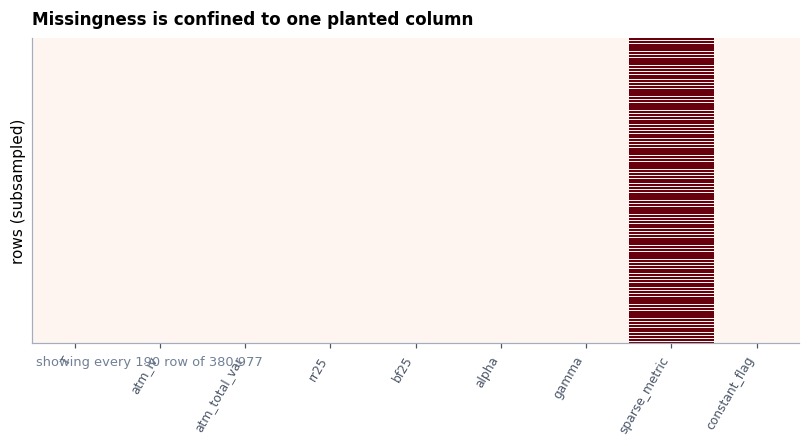

In [34]:
from rvlab.plotting import missingness_map

cols = ["T", "atm_iv", "atm_total_var", "rr25", "bf25", "alpha", "gamma",
        "sparse_metric", "constant_flag"]
missingness_map(df[cols], title="Missingness is confined to one planted column");

## R6.18 · Audit the time axis
<a id="r6-18"></a>

**Topic** Datetime

**Use when** any time series or panel. Span, timezone, monotonicity, duplicates and — the one that matters — the largest gap.

**Inputs** `df` and the name of its time column.

**Needs** nothing beyond the setup and data cells

**Gotchas** gaps are measured between **distinct** timestamps. On a panel the same instant appears once per entity, so differencing the raw column reports a modal gap of zero: true, and useless. A 40-day gap is an outage, and it will quietly become a 40-day-wide rolling window.

**See also** [R6.17](#r6-17) (missing values) · [R1.10](the_volatility_surface.ipynb#r1-10) (timezones)

In [35]:
from rvlab.data import datetime_audit

datetime_audit(df, "ts").to_frame("value")

,value
n,380977
n_unique,32558
n_null,0
tz,UTC
min,2025-08-07 13:35:00+00:00
max,2025-12-12 19:55:00+00:00
monotonic_increasing,False
n_duplicated,348419
modal_gap,0 days 00:01:00
largest_gap,3 days 17:40:00


The gaps over three times the modal spacing are the overnight and weekend breaks. On this intraday panel that is expected; on a daily series it would not be.

In [36]:
gaps = df["ts"].drop_duplicates().sort_values().diff().dropna()
print(f"modal gap {gaps.mode().iloc[0]} · largest {gaps.max()}")
print(gaps.value_counts().head(4).to_string())

modal gap 0 days 00:01:00 · largest 3 days 17:40:00
ts
0 days 00:01:00    32467
0 days 17:40:00       48
0 days 18:36:00       22
2 days 17:40:00       11


## R6.19 · Check categorical cardinality before encoding
<a id="r6-19"></a>

**Topic** Categorical data

**Use when** before one-hot encoding anything. Cardinality and the share of mass in rare levels decide whether encoding is safe or will produce hundreds of near-empty dummies.

**Inputs** `df` with categorical or object columns.

**Needs** nothing beyond the setup and data cells

**Gotchas** `rare_share` is the number to act on. A column where 40% of rows sit in levels seen less than 1% of the time will also produce categories the test set has never seen — which is why `handle_unknown="ignore"` is not optional.

**See also** [R6.14](#r6-14) (near-unique columns are ids) · [R8.25](measuring_and_trading_volatility.ipynb#r8-25) (encoding inside CV)

In [37]:
from rvlab.data import categorical_report

with_cats = df.assign(expiry_str=df["expiry"].astype(str),
                      tenor=pd.cut(df["T"] * 365, [0, 14, 21, 35, 60]).astype(str))
categorical_report(with_cats, columns=["expiry_str", "tenor"], rare_threshold=RARE_LEVEL)

,column,n_unique,top_level,top_share,rare_levels,rare_share
0,expiry_str,100,2025-10-17,0.0390,78,0.4222
1,tenor,4,"(0, 14]",0.4977,0,0.0000


## R6.20 · Detect drift between train and test
<a id="r6-20"></a>

**Topic** Drift

**Use when** before trusting any validation score. Two measures, because they see different things: the KS test is sensitive to a shift anywhere in the distribution, PSI is bucketed and reads as an effect size.

**Inputs** two frames — typically an earlier period and a later one.

**Needs** nothing beyond the setup and data cells

**Gotchas** on large samples KS flags differences far too small to matter, so read the pair. And **a column that drifts is not automatically a column to drop** — it is a column whose relationship with the target you should re-check on recent data.

**See also** [R6.21](#r6-21) (leakage) · [R5.16](the_cross_section.ipynb#r5-16) (splitting in time)

In [38]:
from rvlab.data import drift_report

dates = np.sort(clean["ts"].unique())
cut = dates[int(len(dates) * SPLIT_FRAC)]
train, test = clean[clean["ts"] < cut], clean[clean["ts"] >= cut]
print(f"train {len(train):,} rows to {pd.Timestamp(cut).date()} | test {len(test):,} rows")

drift_report(train, test, columns=["atm_iv", "atm_total_var", "rr25", "bf25", "T"],
             psi_warn=PSI_WARN).round(4)

train 262,971 rows to 2025-10-30 | test 117,886 rows


,column,ref_mean,cur_mean,mean_shift_in_sd,sd_ratio,ks_stat,ks_pvalue,psi,drifted
0,atm_iv,0.1273,0.1516,1.3106,1.2907,0.5006,0.0,1.6133,True
1,atm_total_var,0.0010,0.0015,0.6203,1.4308,0.2124,0.0,0.3871,True
2,bf25,0.0051,0.0041,-0.4892,0.9450,0.2182,0.0,0.3378,True
3,rr25,-0.0440,-0.0499,-0.4830,1.0586,0.1911,0.0,0.3372,True
4,T,0.0594,0.0634,0.1017,1.0372,0.0495,0.0,0.0132,True


> ⚠️ **Interpretation:** volatility features can drift because volatility regimes change — that is not automatically a data bug. A model fitted on the first period is being asked about a different distribution, so its historical validation score may not transfer.

In [39]:
report = drift_report(train, test, columns=["atm_iv", "atm_total_var", "rr25", "bf25", "T"])
drifted = report.query("drifted")["column"].tolist()
print(f"{len(drifted)} of {len(report)} columns flagged by the combined KS/PSI rule: {drifted}")

5 of 5 columns flagged by the combined KS/PSI rule: ['atm_iv', 'atm_total_var', 'bf25', 'rr25', 'T']


## R6.21 · Scan for leakage three ways
<a id="r6-21"></a>

**Topic** Leakage

**Use when** before every fit. A name check, a correlation check and a monotone-relationship check — each catches leaks the others miss.

**Inputs** `df` and the target column name.

**Needs** nothing beyond the setup and data cells

**Gotchas** none of the three is sufficient. A leak with an innocent name and a modest correlation — yesterday's label merged on the wrong date — needs the reasoning in [R3.2](forecasting_the_smile.ipynb#r3-2), not a scan. The scan catches the common case: a future column that survived a join.

**See also** [R3.2](forecasting_the_smile.ipynb#r3-2) (the taxonomy) · [R5.14](the_cross_section.ipynb#r5-14) (the assert form)

In [40]:
from rvlab.data import leakage_scan
from rvlab.features import make_target

labelled = make_target(clean, "bf25", horizon=1)
target_col = labelled.attrs["target"]
leakage_scan(labelled, target_col).head(6)

,column,flags,abs_corr


The clean feature frame produces no flags. Now plant the target under an innocent name: the correlation check should still catch a leak that evaded the name heuristic.

In [41]:
planted = labelled.assign(innocent_name=labelled[target_col] * 1.0001)
found = leakage_scan(planted, target_col)
print(found[["column", "flags", "abs_corr"]].head(4).to_string(index=False))

       column       flags  abs_corr
innocent_name correlation       1.0


## R6.22 · Audit the label itself
<a id="r6-22"></a>

**Topic** Target quality

**Use when** a target problem invalidates everything downstream, so check it separately and early: missingness, balance, tail weight — and missingness **by group**.

**Inputs** `df`, the target column, and optionally a grouping column.

**Needs** R6.21 — run those first. This recipe builds on what they define.

**Gotchas** missing-by-group is the version that matters. A label missing at random costs you rows; a label missing for whole entities biases the model toward whichever entities survived, and no amount of cross-validation will reveal it.

**See also** [R6.20](#r6-20) (drift) · [R5.13](the_cross_section.ipynb#r5-13) (target construction)

In [42]:
from rvlab.data import target_audit

target_audit(labelled, target_col, group="expiry").to_frame("value")

,value
n,380857.0000
n_missing,100.0000
missing_rate,0.0003
n_unique,380399.0000
mean,0.0048
std,0.0020
skew,-0.2449
p99_over_sd,4.5433
groups,100.0000
groups_fully_missing,0.0000


## R6.23 · Reconcile two sources that should agree
<a id="r6-23"></a>

**Topic** Cross-source validation

**Use when** you have two measurements of the same quantity. Whether they agree — and by how much — is a fact about your data that nothing else will tell you.

**Inputs** two frames sharing a key and a comparable column.

**Needs** nothing beyond the setup and data cells

**Gotchas** this repository holds two independent extractions of the same SPY smile: the 1-minute chain panel and a research cache built through a different implied-vol solver. Compare only overlapping composite `(ts, expiry)` keys. Their `atm_iv` gap measures cross-source disagreement; the audit alone cannot determine which extraction is closer to truth.

**See also** [R7.35](seeing_and_joining_evidence.ipynb#r7-35) (the join itself) · [R6.20](#r6-20) (drift)

In [43]:
from rvlab.data import load_chain_panel

panel = load_chain_panel()
panel["ts"] = pd.to_datetime(panel["timestamp_utc"], utc=True)
panel["expiry"] = pd.to_datetime(panel["expiry_date"]).dt.date

both = clean.merge(panel[["ts", "expiry", "atm_iv", "rr25_iv", "bf25_iv", "time_to_expiry"]],
                   on=["ts", "expiry"], how="inner", suffixes=("_cache", "_panel"))
print(f"{len(both):,} rows measured by both pipelines")

1,905 rows measured by both pipelines


The maturities agree to floating-point noise — the two pipelines really are describing the same contracts. The volatilities do not.

In [44]:
comparison = pd.DataFrame({
    "max_abs_diff": [
        (both["T"] - both["time_to_expiry"]).abs().max(),
        (both["atm_iv_cache"] - both["atm_iv_panel"]).abs().max(),
        (both["rr25"] - both["rr25_iv"]).abs().max(),
        (both["bf25"] - both["bf25_iv"]).abs().max()],
}, index=["time_to_expiry", "atm_iv", "rr25", "bf25"])
comparison["median_abs_diff"] = [
    (both["T"] - both["time_to_expiry"]).abs().median(),
    (both["atm_iv_cache"] - both["atm_iv_panel"]).abs().median(),
    (both["rr25"] - both["rr25_iv"]).abs().median(),
    (both["bf25"] - both["bf25_iv"]).abs().median()]
comparison.round(7)

,max_abs_diff,median_abs_diff
time_to_expiry,3.0000e-07,3.0000e-07
atm_iv,2.4991e-03,1.7210e-04
rr25,4.4446e-03,2.0546e-03
bf25,4.8670e-03,1.8783e-03


## R6.24 · Turn the checks into a contract you can re-run
<a id="r6-24"></a>

**Topic** Data contracts

**Use when** once you know what good looks like. A `SchemaSpec` states required columns, kinds, non-null rules, plausible ranges and uniqueness — and can be asserted in CI.

**Inputs** `df`, and the rules you discovered above.

**Needs** nothing beyond the setup and data cells

**Gotchas** ranges are the highest-value part and the part people skip. `0.01 <= atm_iv <= 3.0` catches more real bugs than every dtype check combined, because it encodes domain knowledge that no amount of introspection can infer.

**See also** [R1.12](the_volatility_surface.ipynb#r1-12) (writing one) · [R6.14](#r6-14) (the audit that informs it)

In [45]:
from rvlab.data import SchemaSpec

contract = SchemaSpec(
    name="smile_panel_v2",
    columns={"ts": "datetime", "expiry": "date", "T": "float", "atm_iv": "float"},
    non_null=("ts", "expiry", "T", "atm_iv"),
    ranges={"T": (0.0, 2.0), "atm_iv": (0.01, 3.0), "rr25": (-1.0, 1.0)},
    unique=(("ts", "expiry"),),
    sorted_by="ts",
)
contract.validate(clean)

ValidationReport(name='smile_panel_v2', n_rows=380857, errors=[], warnings=[])

And the same contract against the frame with defects planted — every rule fires at once, which is why `validate` returns a report instead of raising on the first failure.

In [46]:
print(contract.validate(df))

[FAIL] smile_panel_v2 — 380,977 rows
  error   : 120 duplicate rows on ['ts', 'expiry']


## Verdict & what carries forward

The front of the chain: everything the later notebooks quote passes through here first.

### Reading a repository

The tree is inventoried, every format has a loader, and the catalogue records what is present
*and* what is missing. Three things carry forward:

* **Metadata lives in the path more often than you expect.** The `.npy` tensors here have no
  date axis; the run-tree CSVs have no run identity. `load_run_tree`'s `path_fields` is not a
  convenience — without it the concatenated frame cannot be interpreted at all.
* **Concatenating a tree is not the same as gaining data.** [R6.10](#r6-10) found that most
  of the run directories are byte-identical copies: 16 rows, 2 distinct observations. An
  effective sample size of 2 dressed as 16 will pass every downstream check.
* **Absence is information.** Much of this data is gitignored. A catalogue that reports what
  is missing is what lets the rest of the series fall back cleanly instead of raising.

Next in this notebook: **Auditing a dataset, and measuring its uncertainty** — what to verify about the
contents, now that you can read them.

### Auditing a dataset

The audit found what it was meant to find, and one thing it was not:

* **Planted defects, all caught** — the constant column, the mostly-null column, and 120
  duplicated rows, by [R6.14](#r6-14) in a single call.
* **The three outlier methods genuinely disagree.** On the same heavy-tailed sample, z-score
  finds far fewer points than IQR or MAD. The disagreement is the diagnostic: it means
  heavy tails, and heavy tails are a modelling decision rather than a cleaning one.
* **Two independent measurements of the same smile do not agree.** [R6.23](#r6-23) found
  that overlapping composite keys match on maturity to floating-point noise while their
  implied volatilities differ. The audit cannot declare either source correct; the gap is
  cross-source **measurement disagreement**, and it bounds how much of any model's error can
  be interpreted without resolving provenance. Almost nothing else in a standard workflow surfaces it.

Next: [Seeing and Joining Evidence](seeing_and_joining_evidence.ipynb) — because most of what is above is
easier to see than to tabulate.